# Are Symbolic-Regression IV Parametrizations Arbitrage-Free?

Keller-Ressel & Nikulski (2026) use symbolic regression to find analytic
parametrizations of the implied-volatility smile that match market data better,
at lower complexity, than  SVI parametrization that serves as the paper's
point of reference. The form they single out is as follows:

$$ f_4(x) = p_4\big(\tanh(p_1 x)+p_2\big)(p_3+x)+p_5, $$

where $x = \ln(K/F)$ denotes log-moneyness ($K$ strike, $F$ forward) and
$f_4(x)$ models the total implied variance $w(x) = \sigma_{\mathrm{BS}}(x)^2\,\tau$
at maturity $\tau$. 

The paper reports $f_4$ has lower complexity & lower
fitting loss than SVI. Further, it states that static-arbitrage
analysis of $f_4$ is left open, which is addressed by this program. A parametrization that fits better but admits
static arbitrage is unusable for pricing since it implies either negative
risk-neutral density (butterfly arbitrage) or total variance that decreases in
maturity at fixed log-moneyness (calendar arbitrage). We implement SVI &
proposed forms subjecting each to standard std. static no-arbitrage conditions.

**Objective:** Determine whether  symbolic-regression parametrizations of
Keller-Ressel & Nikulski (2026), especially $f_4$, are free of slice-level static
arbitrage (butterfly & tails), and report each form's fit accuracy alongwith
diagnostic outcome.

**Design:** The no-arbitrage diagnostics are first validated on an arbitrage-free SVI slice and Vogt smile of Gatheral & Jacquier
(2014). And then diagnostics are applied to synthetic slices and to a live Deribit surface. Validation is performed on synthetic data. 


## 1. Static no-arbitrage conditions

For a single twice-differentiable slice $w(x) > 0$, absence of static arbitrage
is governed by three conditions (Roper 2009; Gatheral–Jacquier 2014; Lee 2004).

**Positivity:** $w(x) > 0 \, \forall \, x$, automatic when fitting positive total
variances.

**Butterfly (Durrleman's condition):** $g(x) \ge 0 \, \forall \, x$, where

$$
g(x) = \Big(1 - \frac{x\,w'(x)}{2w(x)}\Big)^2 - \frac{w'(x)^2}{4}\Big(\frac{1}{w(x)} + \frac{1}{4}\Big) + \frac{w''(x)}{2}.
$$

This holds for any twice-differentiable slice and is equivalent to
non-negativity of  implied risk-neutral density

$$
p(x) = \frac{g(x)}{\sqrt{2\pi w(x)}} \exp\!\Big(-\tfrac{1}{2} d_-(x)^2\Big), \qquad
d_\pm(x) = -\frac{x}{\sqrt{w(x)}} \pm \frac{\sqrt{w(x)}}{2},
$$

thus, $g \ge 0 \iff p \ge 0$. For SVI specifically, Martini–Mingone (2022) proved
that positivity & $g \ge 0$ is necessary & sufficient. For the
proposed forms it's the operative criterion alongwith tail bound
below, which Roper (2009) shows is necessary & near-sufficient.

**Lee's tail bounds:**  
$\limsup_{x \to \pm\infty} w(x)/|x| \le 2$, required for
finite moments of  risk-neutral density and for boundary behaviour
$d_+(x) \to -\infty$ that completes butterfly characterization.

**Quantitative arbitrage indicator.** Following Keller-Ressel & Nikulski (2026),
we report proportion of negative area in pseudo-density $g$ over a
truncation $[-K, K]$,

$$
\alpha_K = \frac{\int_{-K}^{K} |g(x)|\, \mathbf{1}_{g(x) < 0}\, dx}{\int_{-K}^{K} |g(x)|\, dx} \ge 0,
$$

which vanishes in  absence of butterfly arbitrage and grows with
severity of any violation.

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import least_squares, brentq
from scipy.stats import norm
import matplotlib.pyplot as plt
%matplotlib inline
np.set_printoptions(suppress=True)


# parametrizations of total implied variance w(x) 
# SVI (reparametrized, Keller-Ressel & Nikulski eq. 2.4): 5 params
def svi(x, p1, p2, p3, p4, p5):
    x = np.asarray(x, float)
    return p1 + p2 * x + p3 * np.sqrt((x - p4) ** 2 + p5)

# f4 (eq. 3.1), tanh-based discovery: 5 params
def f4(x, p1, p2, p3, p4, p5):
    x = np.asarray(x, float)
    return p4 * (np.tanh(p1 * x) + p2) * (p3 + x) + p5

# C6_2 (eq. 4.2), two-hump extension for unusual (e.g. W-shaped) smiles: 8 params
def c6(x, p1, p2, p3, p4, p5, p6, p7, p8):
    x = np.asarray(x, float)
    return (p1 + p2 * x + p3 * np.sqrt((x - p4) ** 2 + p5 ** 2)
            + p6 * np.sqrt((x - p7) ** 2 + p8 ** 2))

# C8_1 (eq. 4.3), SVI + sqrt + Gaussian bump: 8 params
def c8(x, p1, p2, p3, p4, p5, p6, p7, p8):
    x = np.asarray(x, float)
    return (p1 + p2 * x + p3 * np.sqrt((x - p4) ** 2 + p5 ** 2)
            + np.sqrt(x ** 2 + p6) + p7 * np.exp(-(x - p8) ** 2))

MODELS = {
    'SVI':  dict(fn=svi, nparams=5, complexity=15),
    'f4':   dict(fn=f4,  nparams=5, complexity=14),
    'C6':   dict(fn=c6,  nparams=8, complexity=None),
    'C8':   dict(fn=c8,  nparams=8, complexity=None),
}
print("parametrizations:", ", ".join(f"{k}({v['nparams']}p)" for k, v in MODELS.items()))

parametrizations: SVI(5p), f4(5p), C6(8p), C8(8p)


## 2. Implementation

The function `gatheral_g` evaluates $g(x)$ via finite-difference derivatives of
$w$ and thus applies to any twice-differentiable slice without
modification. The risk-neutral density is computed via
 closed-form expression of Section 1 and also via Breeden–Litzenberger finite
difference on undiscounted call prices. The two computations serve as a
consistency check on both derivation and numerical implementation.

In [2]:
def _wfun(model_fn, params):
    return lambda x: model_fn(x, *params)


def gatheral_g(w, x, h=1e-5):
    '''Durrleman g(x); >=0 everywhere <=> no butterfly arbitrage. Model-agnostic.
    Returns -inf where w<=0 (inadmissible).'''
    x = np.asarray(x, float)
    W = w(x); Wp = (w(x + h) - w(x - h)) / (2 * h)
    Wpp = (w(x + h) - 2 * W + w(x - h)) / h ** 2
    safe = np.where(W > 0, W, np.nan)
    g = (1 - 0.5 * x * Wp / safe) ** 2 - 0.25 * Wp ** 2 * (1.0 / safe + 0.25) + 0.5 * Wpp
    return np.where(W > 0, g, -np.inf)


def density_formula(w, x):
    '''Implied risk-neutral density via the closed Roper/Gatheral formula.'''
    W = w(x); g = gatheral_g(w, x); dm = -x / np.sqrt(W) - 0.5 * np.sqrt(W)
    return g / np.sqrt(2 * np.pi * W) * np.exp(-0.5 * dm ** 2)


def density_BL(w, x, h=1e-4):
    '''Independent density via Breeden-Litzenberger on undiscounted prices (F=1).'''
    def Ck(k):
        k = np.asarray(k, float); W = w(k); sd = np.sqrt(W)
        d1 = -k / sd + 0.5 * sd; d2 = d1 - sd
        return norm.cdf(d1) - np.exp(k) * norm.cdf(d2)
    d2C = (Ck(x + h) - 2 * Ck(x) + Ck(x - h)) / h ** 2
    dC = (Ck(x + h) - Ck(x - h)) / (2 * h)
    return np.exp(-x) * (d2C - dC)


def alpha_K(w, x_eval):
    g = gatheral_g(w, x_eval)
    ag = np.abs(np.where(np.isfinite(g), g, 0.0))
    neg = np.trapezoid(np.where(g < 0, ag, 0.0), x_eval)
    tot = np.trapezoid(ag, x_eval)
    return float(neg / tot) if tot > 0 else float('nan')


def lee_slopes(w, xfar=80.0):
    '''(left, right) asymptotic tail slopes w(x)/|x|; Lee requires both <= 2.'''
    return float(w(-xfar) / xfar), float(w(xfar) / xfar)


def arbitrage_report(w, x_eval):
    '''Static-arbitrage battery on an explicit (quoted-range) evaluation grid.
    Positivity gates the verdict: a fit with negative total variance in range is
    inadmissible, and its butterfly metrics are not meaningful (reported NaN).
    Lee is an asymptotic diagnostic.'''
    W = w(x_eval)
    pos_ok = bool(np.all(W > 0))
    lo, hi = lee_slopes(w)
    base = dict(positivity_ok=pos_ok, lee_left=lo, lee_right=hi,
                lee_ok=bool(lo <= 2 and hi <= 2))
    if not pos_ok:
        return dict(butterfly_ok=False, min_g=float('nan'),
                    min_density=float('nan'), alpha_K=float('nan'), **base)
    g = gatheral_g(w, x_eval); d = density_formula(w, x_eval)
    return dict(butterfly_ok=bool(np.all(g >= -1e-8)),
                min_g=float(np.nanmin(g)), min_density=float(np.nanmin(d)),
                alpha_K=alpha_K(w, x_eval), **base)

## 3. Validation on slices with known arbitrage status

Before applying diagnostics to proposed forms, we verify that they
return correct outcome on slices for which answer is known in advance.
An arbitrage-free SVI slice should satisfy all three conditions of Section 1.
The Vogt smile, i.e., the canonical butterfly-arbitrageable SVI parametrization
of Gatheral & Jacquier (2014), should violate Durrleman's condition which should be identified in same region of log-moneyness by both
$g(x)$ and independent Breeden–Litzenberger density.

In [3]:
# (i) an arbitrage-free SVI slice
afree = (0.012, 0.05, 0.10, 0.0, 0.02)          # mild, well-behaved
w_afree = _wfun(svi, afree)
xv = np.linspace(-1.5, 1.5, 800)
rep_afree = arbitrage_report(w_afree, xv)

# (ii) the Vogt smile (known butterfly arbitrage). Raw SVI -> reparam eq.2.4:
#     raw (a,b,rho,m,s): p1=a-b*rho*m, p2=b*rho, p3=b, p4=m, p5=s^2
a, b, rho, m, s = -0.0410, 0.1331, 0.3060, 0.3586, 0.4153
vogt = (a - b * rho * m, b * rho, b, m, s ** 2)
w_vogt = _wfun(svi, vogt)
rep_vogt = arbitrage_report(w_vogt, xv)

print("arbitrage-free SVI :", {k: round(v, 4) if isinstance(v, float) else v
                               for k, v in rep_afree.items()})
print("Vogt smile         :", {k: round(v, 4) if isinstance(v, float) else v
                               for k, v in rep_vogt.items()})

# confirm g and the independent BL density flag the SAME region on Vogt
xx = np.linspace(-1.5, 1.5, 600)
g_neg = gatheral_g(w_vogt, xx) < -1e-9
d_neg = density_BL(w_vogt, xx) < -1e-9
assert rep_afree['butterfly_ok'] and not rep_vogt['butterfly_ok']
assert g_neg.any() and d_neg.any() and np.mean(g_neg == d_neg) > 0.99
print("\nVALIDATION PASSED: arb-free slice clean; Vogt flagged by g AND density,",
      "same region, identical verdicts.")

arbitrage-free SVI : {'butterfly_ok': True, 'min_g': 0.2542, 'min_density': 0.0, 'alpha_K': 0.0, 'positivity_ok': True, 'lee_left': 0.0502, 'lee_right': 0.1502, 'lee_ok': True}
Vogt smile         : {'butterfly_ok': False, 'min_g': -0.0329, 'min_density': -0.0001, 'alpha_K': 0.013, 'positivity_ok': True, 'lee_left': 0.0923, 'lee_right': 0.1725, 'lee_ok': True}

VALIDATION PASSED: arb-free slice clean; Vogt flagged by g AND density, same region, identical verdicts.


## 4. Fitting

Each form is fitted to a slice by weighted least squares on total variance:
$$
\min_p \sum_i \omega(x_i)\,\big(w(x_i; p) - w_i\big)^2,
\qquad
\omega(x) = \exp\!\Big(-\tfrac{x^2}{2\ell^2}\Big),
$$

The weight $\omega$ is a parametric approximation to the maximum-likelihood
weight under independent Gaussian price-quote noise of common variance.
Linearizing the Black–Scholes price around $w$ gives $\delta w \approx
(2\sqrt{w}/\nu)\,\delta C$, with $\nu(x) = F\sqrt{\tau}\,\varphi(d_1)$. The implied-variance errors are then heteroskedastic with
variance proportional to $w(x)/\nu(x)^2$, so the maximum-likelihood weight is
$\omega^{\star}(x) \propto \nu(x)^2 / w(x)$. Since $\nu \propto \varphi(d_1)$. This weight is approximately Gaussian in log-moneyness with peak near $x = 0$,
and $\omega(x) = \exp(-x^2/(2\ell^2))$ is the one-parameter Gaussian proxy
adopted here, with bandwidth $\ell$ chosen empirically.


The discovered forms carry more parameters than SVI (eight for C6 and C8
versus five), and some of those parameters appear under square roots. The
fits are thus solved as bounded least-squares problems with a
trust-region algorithm, initialized per model.

In [4]:
def fit_slice(model_fn, nparams, x, w, x0=None, bounds=None, ell=0.5):
    x = np.asarray(x, float); w = np.asarray(w, float)
    omega = np.exp(-x ** 2 / (2 * ell ** 2)) + 1e-3
    sw = np.sqrt(omega / omega.sum())
    if x0 is None:
        x0 = _default_x0(model_fn, nparams, x, w)
    if bounds is None:
        bounds = _default_bounds(model_fn, nparams)
    resid = lambda p: sw * (model_fn(x, *p) - w)
    sol = least_squares(resid, x0, bounds=bounds, method='trf', max_nfev=20000)
    p = sol.x
    rmse = float(np.sqrt(np.mean((model_fn(x, *p) - w) ** 2)))
    return p, rmse


def _default_bounds(model_fn, n):
    '''Keep parameters that sit under a square root non-negative, so the model
    stays real-valued during optimization (else least_squares hits NaNs).'''
    lo = [-np.inf] * n; hi = [np.inf] * n
    if model_fn is svi:
        lo[4] = 1e-8            # p5 in sqrt((x-p4)^2 + p5)
    if model_fn is c8:
        lo[5] = 1e-8            # p6 in sqrt(x^2 + p6)
    return (lo, hi)


def _default_x0(model_fn, nparams, x, w):
    wmin = max(float(w.min()), 1e-6); xmin = float(x[np.argmin(w)])
    if model_fn is svi:
        return [wmin, 0.0, 0.1, xmin, 0.02]
    if model_fn is f4:
        return [2.0, 0.5, xmin, 0.05, wmin]
    if model_fn is c6:
        return [wmin, 0.0, 0.05, xmin - 0.1, 0.05, 0.05, xmin + 0.1, 0.05]
    if model_fn is c8:
        return [wmin, 0.0, 0.05, xmin, 0.05, 0.01, 0.0, 0.0]
    return [0.1] * nparams


def fit_and_test(models, x, w, T=1.0, margin=0.0):
    x = np.asarray(x, float)
    x_eval = np.linspace(x.min() - margin, x.max() + margin, 800)
    rows = []
    fits = {}
    for name, spec in models.items():
        p, rmse = fit_slice(spec['fn'], spec['nparams'], x, w)
        wf = _wfun(spec['fn'], p)
        rep = arbitrage_report(wf, x_eval)
        fits[name] = (p, wf, rmse)
        atm = wf(0.0)
        rows.append(dict(model=name, n_params=spec['nparams'],
                         rmse_w=round(rmse, 6),
                         rmse_volpts=round(rmse / (2 * np.sqrt(atm * T)) * 100, 3) if atm > 0 else np.nan,
                         positivity_ok=rep['positivity_ok'],
                         butterfly_ok=rep['butterfly_ok'],
                         min_g=round(rep['min_g'], 4),
                         alpha_K=round(rep['alpha_K'], 4),
                         lee_ok=rep['lee_ok']))
    return pd.DataFrame(rows).set_index('model'), fits

## 5. Application I: Representative slice (SVI vs $f_4$)

A representative slice is generated from valid SVI parameters with additive
Gaussian noise in implied volatility after which SVI & $f_4$ are fitted to
the noisy quotes and no-arbitrage diagnostics are applied to each fit. The
slice is generated from SVI by design. The comparison here isolates
question of whether $f_4$ remains free of static arbitrage on a smile that
SVI can represent exactly. SVI consequently achieves lowest fitting error
by construction. The comparison of interest is whether $f_4$ stays competitive
in fit & arbitrage-free in conclusion. The paper's accuracy claim for $f_4$
is established on empirical SPX data. 

In [5]:
rng = np.random.default_rng(0)
true_p = (0.030, -0.020, 0.090, 0.00, 0.015)     # arb-free SVI, mild neg skew
T = 0.25
xg = np.linspace(-0.7, 0.7, 40)
w_true = svi(xg, *true_p)
w_noisy = (np.sqrt(w_true / T) + rng.normal(0, 0.004, xg.shape)) ** 2 * T

normal_table, normal_fits = fit_and_test(
    {k: MODELS[k] for k in ['SVI', 'f4']}, xg, w_noisy, T=T)
print(normal_table.to_string())

       n_params    rmse_w  rmse_volpts  positivity_ok  butterfly_ok   min_g  alpha_K  lee_ok
model                                                                                       
SVI           5  0.000671        0.329           True          True  0.3731      0.0    True
f4            5  0.000709        0.346           True          True  0.3979      0.0    True


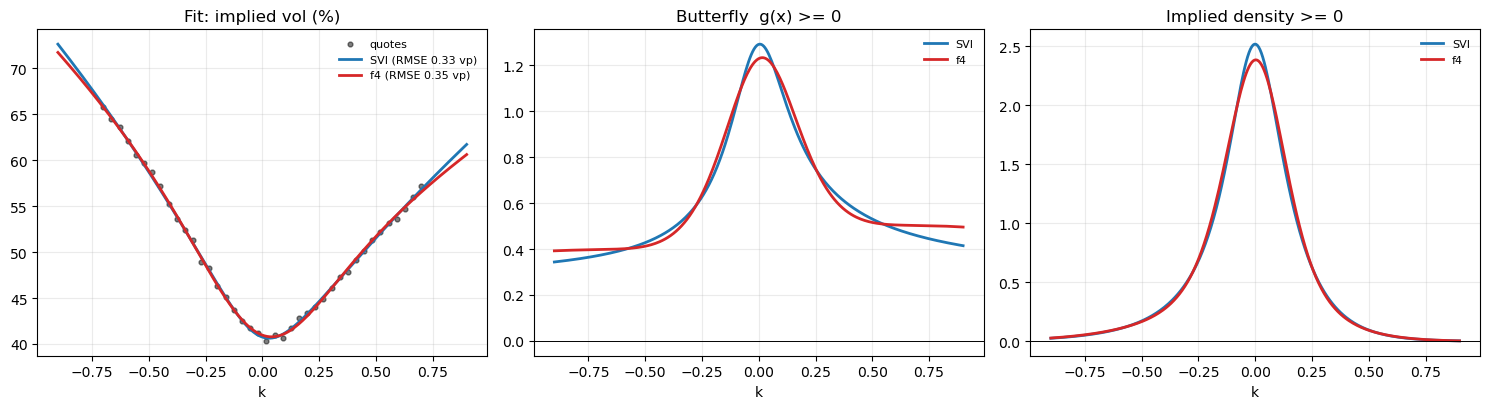

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
kk = np.linspace(-0.9, 0.9, 300)
cols = {'SVI': '#1f77b4', 'f4': '#d62728'}
ax[0].scatter(xg, np.sqrt(w_noisy / T) * 100, s=12, c='k', alpha=0.5, label='quotes')
for name in ['SVI', 'f4']:
    _, wf, rmse = normal_fits[name]
    ax[0].plot(kk, np.sqrt(np.maximum(wf(kk), 1e-9) / T) * 100, c=cols[name], lw=2,
               label=f'{name} (RMSE {rmse/(2*np.sqrt(wf(0.0)*T))*100:.2f} vp)')
    ax[1].plot(kk, gatheral_g(wf, kk), c=cols[name], lw=2, label=name)
    ax[2].plot(kk, density_formula(wf, kk), c=cols[name], lw=2, label=name)
ax[0].set_title('Fit: implied vol (%)'); ax[0].set_xlabel('k'); ax[0].legend(frameon=False, fontsize=8)
ax[1].axhline(0, c='k', lw=0.7); ax[1].set_title('Butterfly  g(x) >= 0'); ax[1].set_xlabel('k'); ax[1].legend(frameon=False, fontsize=8)
ax[2].axhline(0, c='k', lw=0.7); ax[2].set_title('Implied density >= 0'); ax[2].set_xlabel('k'); ax[2].legend(frameon=False, fontsize=8)
for a in ax: a.grid(alpha=0.25)
fig.tight_layout(); plt.show()

## 6. Application II : Bimodal-mixture smile

The C6 & C8 forms are constructed to fit smiles outside SVI's image. We
construct such a smile from a two-component lognormal mixture with separated
component forwards $\mu_1, \mu_2$ and weights $w_1, w_2$ satisfying
martingale condition $w_1\mu_1 + w_2\mu_2 = F$ (Glasserman & Pirjol, 2023). The resulting risk-neutral density is bimodal,
producing an implied-volatility slice with a central hump that SVI, being
convex in $x$, cannot reproduce.

Because the mixture is a martingale at $F$ and each component is a valid
log-normal price model, the mixture price surface is arbitrage-free by
construction, so the target smile is admissible. The substantive
question is whether each parametrization's fit remains arbitrage-free.
SVI's fit to such a smile is necessarily poor. We determine whether C6 & C8 fit it accurately while satisfying Durrleman's condition. Lee's tail bound is reported separately as fitted tails of these forms extrapolate well beyond  quoted range.




In [7]:
def mixture_w(xg, T=0.25, F=1.0, mus=(0.80, 1.20), vols=(0.18, 0.18), wts=(0.5, 0.5)):
    '''Bimodal-mixture smile from a 2-lognormal mixture; martingale since
    sum w_i mu_i = F, so the target is arbitrage-free by construction.'''
    K = F * np.exp(xg)
    def bs_call(Fwd, K, T, sig):
        sd = sig * np.sqrt(T); d1 = (np.log(Fwd / K) + 0.5 * sd ** 2) / sd; d2 = d1 - sd
        return Fwd * norm.cdf(d1) - K * norm.cdf(d2)
    price = sum(wt * bs_call(mu, K, T, v) for wt, mu, v in zip(wts, mus, vols))
    iv = []
    for Ki, Pi in zip(K, price):
        intrinsic = max(F - Ki, 0.0)
        try:
            iv.append(brentq(lambda s: bs_call(F, Ki, T, s) - Pi, 1e-3, 5.0) if Pi > intrinsic + 1e-12 else np.nan)
        except ValueError:
            iv.append(np.nan)
    iv = np.array(iv)
    return iv ** 2 * T, iv

xw = np.linspace(-0.45, 0.45, 40)
w_w, iv_w = mixture_w(xw)
ok = np.isfinite(w_w)
W_table, W_fits = fit_and_test(MODELS, xw[ok], w_w[ok], T=0.25)
print("Bimodal-mixture smile (2-lognormal mixture):\n")
print(W_table.to_string())

Bimodal-mixture smile (2-lognormal mixture):

       n_params    rmse_w  rmse_volpts  positivity_ok  butterfly_ok   min_g  alpha_K  lee_ok
model                                                                                       
SVI           5  0.002156        0.864           True         False -5.7328   0.0353    True
f4            5  0.001516        0.601           True         False -0.0296   0.0003    True
C6            8  0.000110        0.044           True          True  0.1702   0.0000    True
C8            8  0.000756        0.301           True          True  0.3774   0.0000   False


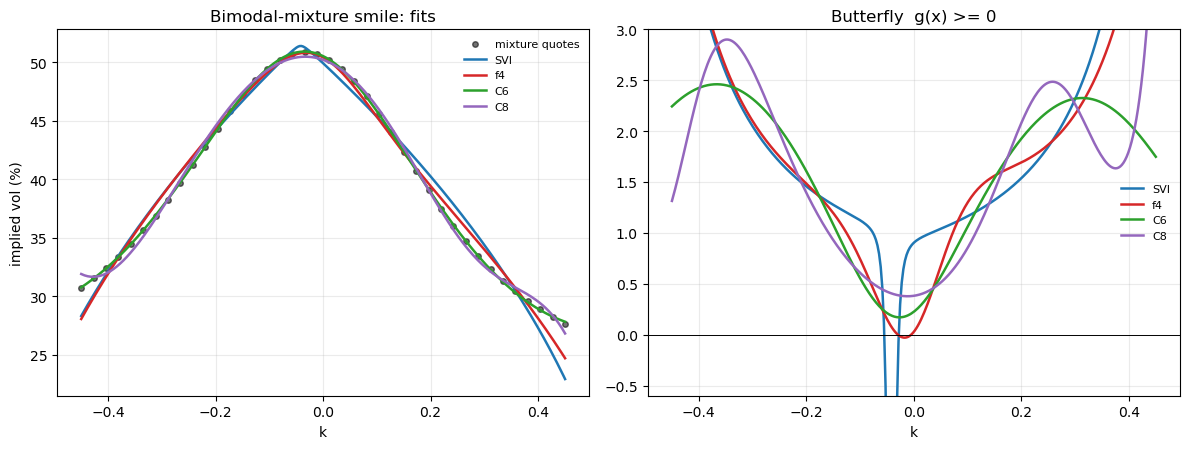

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
kk = np.linspace(xw[ok].min(), xw[ok].max(), 300)
cset = {'SVI': '#1f77b4', 'f4': '#d62728', 'C6': '#2ca02c', 'C8': '#9467bd'}
ax[0].scatter(xw[ok], iv_w[ok] * 100, s=16, c='k', alpha=0.55, label='mixture quotes')
for name in MODELS:
    _, wf, _ = W_fits[name]
    ax[0].plot(kk, np.sqrt(np.maximum(wf(kk), 1e-9) / 0.25) * 100, c=cset[name], lw=1.8, label=name)
    ax[1].plot(kk, gatheral_g(wf, kk), c=cset[name], lw=1.8, label=name)
ax[0].set_title('Bimodal-mixture smile: fits'); ax[0].set_xlabel('k'); ax[0].set_ylabel('implied vol (%)'); ax[0].legend(frameon=False, fontsize=8)
ax[1].axhline(0, c='k', lw=0.7); ax[1].set_ylim(-0.6, 3.0); ax[1].set_title('Butterfly  g(x) >= 0'); ax[1].set_xlabel('k'); ax[1].legend(frameon=False, fontsize=8)
for a in ax: a.grid(alpha=0.25)
fig.tight_layout(); plt.show()

## 7. Application III: Live Deribit slice

The no-arbitrage diagnostics are applied to real market quotes. Implied
volatilities and forwards are retrieved from Deribit's public market data
endpoint. Each parametrization is fitted to most-liquid available
maturity, and fitting error & arbitrage status are reported.

In [9]:
import json, urllib.request
from datetime import datetime, timezone

DERIBIT = 'https://www.deribit.com/api/v2/public/'
_M = {m.upper(): i for i, m in enumerate(['', 'jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec'])}

def _get(method, **params):
    qs = '&'.join(f'{k}={v}' for k, v in params.items())
    with urllib.request.urlopen(f'{DERIBIT}{method}?{qs}', timeout=30) as r:
        return json.loads(r.read().decode())['result']

def fetch_deribit_slice(currency='BTC', target_expiry=None):
    '''Return (x, w, expiry, T) for the most-liquid expiry (or a chosen one).'''
    now = int(datetime.now(timezone.utc).timestamp() * 1000)
    summ = _get('get_book_summary_by_currency', currency=currency, kind='option')
    rows = {}
    for sdic in summ:
        parts = sdic['instrument_name'].split('-')
        if len(parts) != 4:
            continue
        _, tok, strike, cp = parts
        F = sdic.get('underlying_price'); iv = sdic.get('mark_iv')
        if not F or not iv or iv <= 0:
            continue
        d, mo, yr = int(tok[:-5]), _M[tok[-5:-2]], 2000 + int(tok[-2:])
        T = (datetime(yr, mo, d, 8, tzinfo=timezone.utc).timestamp() * 1000 - now) / (365 * 86400 * 1000)
        if T <= 5 / 365:
            continue
        rows.setdefault(tok, []).append((np.log(float(strike) / F), (iv / 100) ** 2 * T, T))
    if not rows:
        return None
    tok = target_expiry or max(rows, key=lambda t: len(rows[t]))
    arr = np.array(sorted(rows[tok])); 
    return arr[:, 0], arr[:, 1], tok, float(arr[0, 2])

try:
    x_live, w_live, exp_live, T_live = fetch_deribit_slice('BTC')
    print(f'Deribit BTC expiry {exp_live}: {len(x_live)} quotes, T={T_live:.3f}\n')
    live_table, live_fits = fit_and_test(MODELS, x_live, w_live, T=T_live)
    print(live_table.to_string())
except Exception as e:
    print(f'Live fetch did not run here ({type(e).__name__}). Run on a networked machine.')

Deribit BTC expiry 26JUN26: 118 quotes, T=0.067

       n_params    rmse_w  rmse_volpts  positivity_ok  butterfly_ok   min_g  alpha_K  lee_ok
model                                                                                       
SVI           5  0.007747       16.966           True          True  0.1343      0.0    True
f4            5  0.004093        8.746           True          True  0.0783      0.0    True
C6            8  0.006553       14.000           True          True  0.0560      0.0    True
C8            8  0.003026        6.395           True          True  0.0113      0.0    True


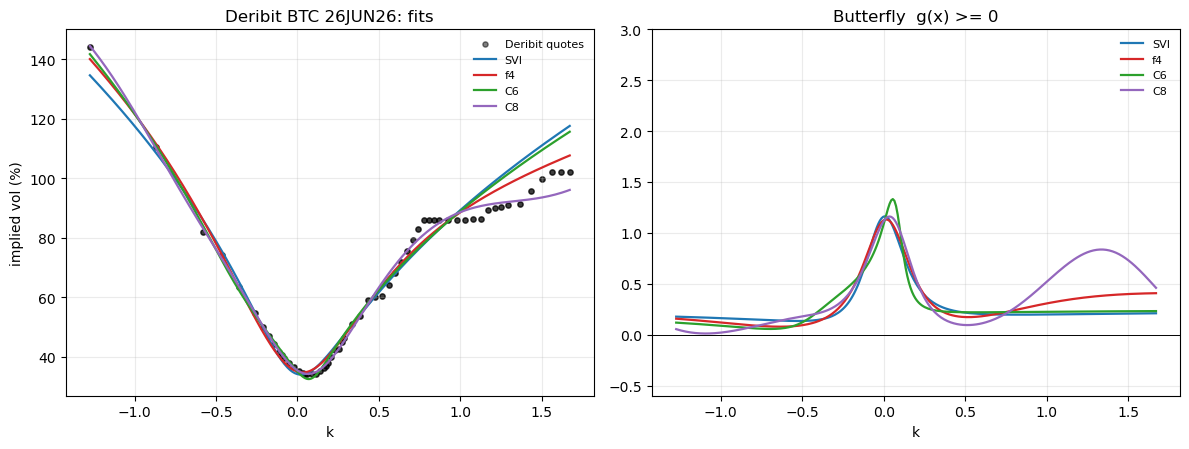

In [10]:
try:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
    kk = np.linspace(x_live.min(), x_live.max(), 300)
    ax[0].scatter(x_live, np.sqrt(w_live / T_live) * 100, s=14, c='k', alpha=0.5, label='Deribit quotes')
    for name in MODELS:
        _, wf, _ = live_fits[name]
        ax[0].plot(kk, np.sqrt(np.maximum(wf(kk), 1e-9) / T_live) * 100, c=cset[name], lw=1.6, label=name)
        ax[1].plot(kk, gatheral_g(wf, kk), c=cset[name], lw=1.6, label=name)
    ax[0].set_title(f'Deribit BTC {exp_live}: fits'); ax[0].set_xlabel('k'); ax[0].set_ylabel('implied vol (%)'); ax[0].legend(frameon=False, fontsize=8)
    ax[1].axhline(0, c='k', lw=0.7); ax[1].set_ylim(-0.6, 3.0); ax[1].set_title('Butterfly  g(x) >= 0'); ax[1].set_xlabel('k'); ax[1].legend(frameon=False, fontsize=8)
    for a in ax: a.grid(alpha=0.25)
    fig.tight_layout(); plt.show()
except NameError:
    print('Run the live-fetch cell first.')

## 8. Results & Limitations 

The trade-off tables present an answer to question Keller-Ressel & Nikulski (2026) leaves open.
For each parametrization, the fitting error & parameter count appear next to
the butterfly indicator, the quantitative arbitrage indicator $\alpha_K$, and
the Lee tail bound. A parametrization that reduces fitting error while raising
$\alpha_K$ above that of SVI trades absence of arbitrage for fit accuracy.

**Limitations.**

- The diagnostics test static arbitrage at a single maturity (butterfly &
  Lee's tail bound). Surface-level admissibility additionally requires absence
  of calendar arbitrage, i.e. total variance non-decreasing in $\tau$ at fixed
  $x$. So, the conclusion is per-slice instead of surface-wide,
  and extends to full surface only after a multi-maturity fit verifies
  calendar consistency.

- For SVI under positivity, Durrleman's $g \ge 0$ is necessary * sufficient
  (Martini & Mingone, 2022), so the diagnostic is decisive. For the proposed
  forms, $g \ge 0$ alongwith Lee bound is necessary and close to
  sufficient (Roper, 2009), but a sufficiency theorem has not been established.

- The bimodal-mixture slice is synthetic & arbitrage-free by construction,
  so it tests whether each parametrization's fit preserves admissibility on
  controlled data. The empirical claim that C6 and C8 outperform SVI on real
  non-SVI smiles requires testing on
  market data with such features. 

- The fit comparisons depend on weighting scheme.Gaussian moneyness
  weight used here approximates max-likelihood weight under
  homoskedastic Gaussian price noise (Section 4). Weights inversely
  proportional to quote bid–ask spread are more appropriate when
  two-sided quotes are available and may alter relative fit ranking.

## 9. Conclusion

The static-arbitrage analysis Keller-Ressel & Nikulski (2026) leave open for
the discovered parametrizations is carried out here and parametrizations
pass it. On a representative slice, $f_4$ is competitive with SVI and free of
butterfly arbitrage. On a bimodal-mixture slice SVI cannot represent, C6 &
C8 fit substantially better and keep $g \ge 0$ (0.04 and 0.30
implied-volatility points against SVI's 0.86), while SVI's fit violates
Durrleman's condition. On a live Deribit BTC slice, $f_4$ & C8 reduce
fitting error to roughly half of SVI's (8.7 and 6.4 against 17.0), all four
forms butterfly-arbitrage-free on the quoted range. The result is slice-level
and for the proposed forms, the conditions are necessary and close to
sufficient rather than fully sufficient (as per Section 8).

## References

- Gatheral, J., & Jacquier, A. (2014). Arbitrage-free SVI volatility surfaces.
*Quantitative Finance*, *14*(1), 59–71.
https://doi.org/10.1080/14697688.2013.819986

- Glasserman, P., & Pirjol, D. (2023). W-shaped implied volatility curves and the
Gaussian mixture model. *Quantitative Finance*, *23*(4), 557–577.
https://doi.org/10.1080/14697688.2023.2165448

- Keller-Ressel, M., & Nikulski, H. (2026). *Discovering parametrizations of
implied volatility with symbolic regression* (arXiv:2603.21892). arXiv.
https://doi.org/10.48550/arXiv.2603.21892

- Lee, R. W. (2004). The moment formula for implied volatility at extreme strikes.
*Mathematical Finance*, *14*(3), 469–480.
https://doi.org/10.1111/j.0960-1627.2004.00200.x

- Martini, C., & Mingone, A. (2022). No arbitrage SVI. *SIAM Journal on Financial
Mathematics*, *13*(1), 227–261. https://doi.org/10.1137/20M1351060


- Roper, M. P. V. (2009). *Implied volatility: General properties and asymptotics* [Thesis] UNSW Sydney. https://doi.org/10.26190/unsworks/21796


